# 🤖 Notebook 03.4 — Vision Transformer (ViT-B/16)
**Results:** Accuracy = 0.9780 | F1 = 0.9780 | ROC-AUC = **0.9999**  
**Strategy:** Freeze encoder → train head → optional partial unfreeze (last 4 blocks)  
**Normalisation:** ImageNet `[0.485,0.456,0.406]` / `[0.229,0.224,0.225]`  
**Note:** Highest AUC but 430× more parameters than Custom CNN — too heavy for real-time.

In [ ]:
import os, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from google.colab import drive, files

drive.mount('/content/drive')
# ╔══════════════════════════════════════════════════════════╗
# ║          PROJECT-WIDE CONSTANTS — do not change          ║
# ║  These must be identical across all notebooks & scripts  ║
# ╚══════════════════════════════════════════════════════════╝
DATASET_PATH   = '/content/drive/MyDrive/dataset_final'   # split dataset
FRAMES_PATH    = '/content/drive/MyDrive/dataset_frames'  # raw frames
CLASS_NAMES    = ['cheating', 'not_cheating']             # alphabetical (ImageFolder order)
IMG_SIZE       = (224, 224)
BATCH_SIZE     = 32
NUM_EPOCHS     = 20
PATIENCE       = 5

# ── Best model (chosen from Notebook 04 results) ─────────────
# Custom CNN: Acc=0.9780, F1=0.9780, ROC-AUC=0.9995, Params=~200K
# Lightest AND best ROC-AUC → perfect for real-time inference
BEST_MODEL_NAME = 'Custom CNN'
BEST_MODEL_FILE = 'cnn_cheating_model.pth'
BEST_MODEL_KEY  = 'cnn'

# Normalisation for Custom CNN (trained from scratch — NOT ImageNet)
CLF_MEAN = [0.5, 0.5, 0.5]
CLF_STD  = [0.5, 0.5, 0.5]

# All model .pth filenames (for reference / comparison notebook)
MODEL_FILES = {
    'cnn':          'cnn_cheating_model.pth',
    'resnet18':     'resnet18_cheating_model.pth',
    'efficientnet': 'efficientnet_cheating.pth',
    'vit':          'Vision_Transformer.pth',
    'mobilenet':    'mobilenetv2_model.pth',
}


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_data = datasets.ImageFolder(f"{DATASET_PATH}/train", transform=train_tf)
val_data   = datasets.ImageFolder(f"{DATASET_PATH}/val",   transform=eval_tf)
test_data  = datasets.ImageFolder(f"{DATASET_PATH}/test",  transform=eval_tf)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"Train  : {len(train_data)}  Val: {len(val_data)}  Test: {len(test_data)}")
print(f"Classes: {train_data.classes}")

def unnorm(t, mean, std):
    t = t.clone()
    for c, m, s in zip(range(3), mean, std): t[c] = t[c]*s + m
    return t.clamp(0,1)


Device : cuda
Train  : 1450  Val: 182  Test: 182
Classes: ['cheating', 'not_cheating']


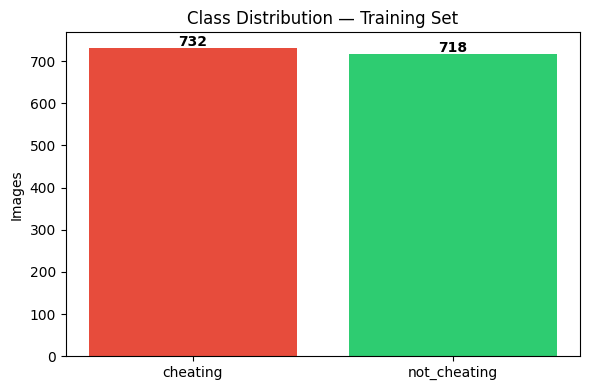

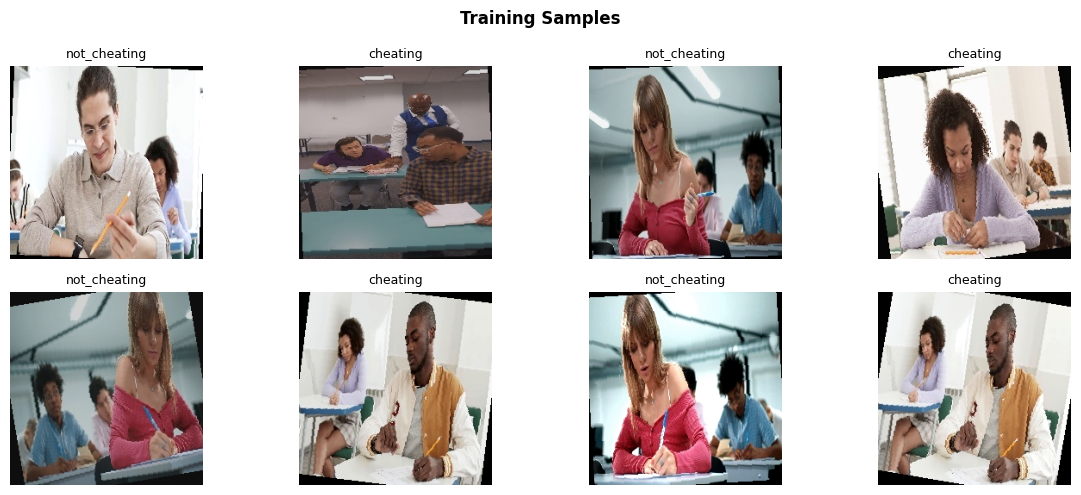

In [ ]:
# Class distribution
counts = [len(os.listdir(f"{DATASET_PATH}/train/{c}")) for c in CLASS_NAMES]
plt.figure(figsize=(6,4))
bars = plt.bar(CLASS_NAMES, counts, color=["#E74C3C","#2ECC71"])
for bar,c in zip(bars,counts): plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(c), ha="center", fontweight="bold")
plt.title("Class Distribution — Training Set"); plt.ylabel("Images"); plt.tight_layout(); plt.show()

# Sample images
imgs, lbls = next(iter(train_loader))
plt.figure(figsize=(12,5))
for i in range(8):
    plt.subplot(2,4,i+1); plt.imshow(unnorm(imgs[i],MEAN,STD).permute(1,2,0)); plt.title(CLASS_NAMES[lbls[i]],fontsize=9); plt.axis("off")
plt.suptitle("Training Samples", fontweight="bold"); plt.tight_layout(); plt.show()


In [ ]:
from torchvision.models import vit_b_16, ViT_B_16_Weights
MODEL_NAME = "ViT-B/16"
MODEL_SAVE = MODEL_FILES["vit"]

model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
for p in model.parameters(): p.requires_grad=False
head_in = model.heads.head.in_features
model.heads = nn.Sequential(nn.Linear(head_in,256),nn.ReLU(inplace=True),nn.Dropout(0.4),nn.Linear(256,2))
model = model.to(device)
total=sum(p.numel() for p in model.parameters())
trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ ViT-B/16 | Total: {total:,} | Trainable: {trainable:,}")


✅ ViT-B/16 | Total: 85,996,034 | Trainable: 197,378


In [ ]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.heads.parameters(),lr=1e-3,weight_decay=1e-4)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=0.5,patience=2)

In [ ]:
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc, best_wts, patience_count = 0.0, copy.deepcopy(model.state_dict()), 0

for epoch in range(NUM_EPOCHS):
    model.train()
    rl=rc=rt=0
    for imgs,lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False):
        imgs,lbls = imgs.to(device),lbls.to(device)
        optimizer.zero_grad(); out=model(imgs); loss=criterion(out,lbls); loss.backward(); optimizer.step()
        rl+=loss.item(); _,p=torch.max(out,1); rc+=(p==lbls).sum().item(); rt+=lbls.size(0)
    tl,ta = rl/len(train_loader), rc/rt

    model.eval(); vl=vc=vt=0
    with torch.no_grad():
        for imgs,lbls in val_loader:
            imgs,lbls=imgs.to(device),lbls.to(device); out=model(imgs); loss=criterion(out,lbls)
            vl+=loss.item(); _,p=torch.max(out,1); vc+=(p==lbls).sum().item(); vt+=lbls.size(0)
    vla,va = vl/len(val_loader), vc/vt

    train_losses.append(tl); val_losses.append(vla); train_accs.append(ta); val_accs.append(va)
    scheduler.step(va)

    if va > best_val_acc:
        best_val_acc,best_wts,patience_count = va,copy.deepcopy(model.state_dict()),0; status="✅ best"
    else:
        patience_count+=1; status=f"⚠ ({patience_count}/{PATIENCE})"

    print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS} | Train loss {tl:.4f} acc {ta:.4f} | Val loss {vla:.4f} acc {va:.4f} | {status}")
    if patience_count >= PATIENCE: print("🛑 Early stopping."); break

model.load_state_dict(best_wts)
print(f"\n🏆 Best val acc: {best_val_acc:.4f}")


Epoch  1/20 | Train loss 0.2355 acc 0.9076 | Val loss 0.0670 acc 0.9835 | ✅ best


Epoch  2/20 | Train loss 0.0765 acc 0.9703 | Val loss 0.0457 acc 0.9780 | ⚠ (1/5)


Epoch  3/20 | Train loss 0.0501 acc 0.9855 | Val loss 0.0240 acc 0.9945 | ✅ best


Epoch  4/20 | Train loss 0.0438 acc 0.9814 | Val loss 0.0282 acc 0.9780 | ⚠ (1/5)


Epoch  5/20 | Train loss 0.0394 acc 0.9855 | Val loss 0.0184 acc 0.9945 | ⚠ (2/5)


Epoch  6/20 | Train loss 0.0345 acc 0.9862 | Val loss 0.0302 acc 0.9780 | ⚠ (3/5)


Epoch  7/20 | Train loss 0.0276 acc 0.9897 | Val loss 0.0160 acc 0.9945 | ⚠ (4/5)


Epoch  8/20 | Train loss 0.0255 acc 0.9876 | Val loss 0.0180 acc 0.9945 | ⚠ (5/5)
🛑 Early stopping.

🏆 Best val acc: 0.9945


In [ ]:
# ── Phase 2 (optional): unfreeze last 4 encoder blocks
for i,block in enumerate(model.encoder.layers):
    if i >= len(model.encoder.layers)-4:
        for p in block.parameters(): p.requires_grad=True
optimizer=optim.Adam([{"params":model.heads.parameters(),"lr":1e-3},{"params":[p for p in model.encoder.parameters() if p.requires_grad],"lr":5e-6}],weight_decay=1e-4)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=0.5,patience=2)


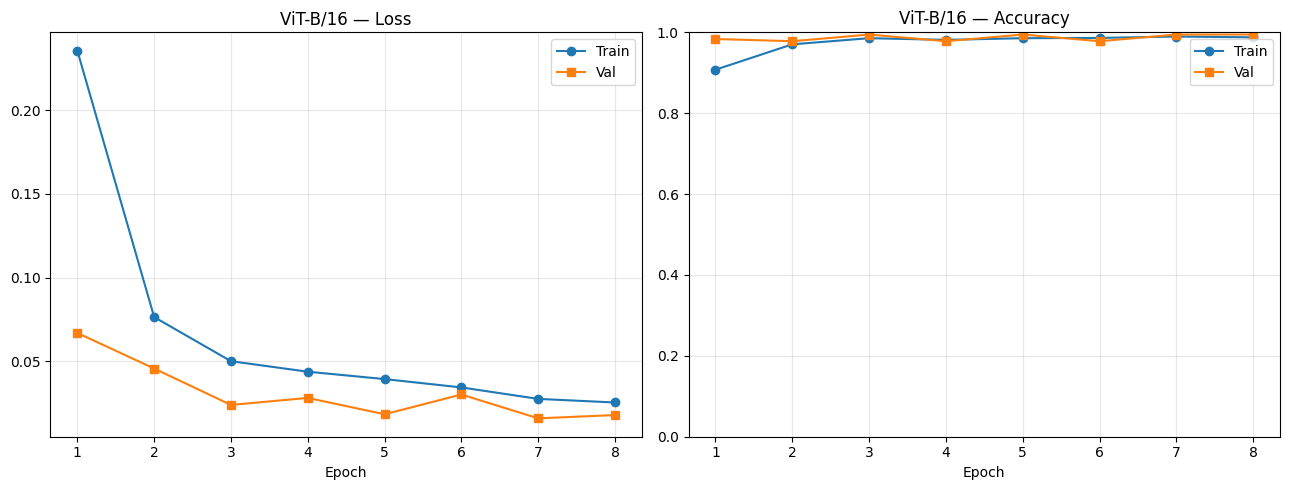

Train Acc: 0.9876 | Val Acc: 0.9945 | Gap: 0.0069


In [ ]:
epochs_r=range(1,len(train_losses)+1)
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].plot(epochs_r,train_losses,"o-",label="Train"); ax[0].plot(epochs_r,val_losses,"s-",label="Val")
ax[0].set_title(f"{MODEL_NAME} — Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(epochs_r,train_accs,"o-",label="Train"); ax[1].plot(epochs_r,val_accs,"s-",label="Val")
ax[1].set_title(f"{MODEL_NAME} — Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].set_ylim(0,1); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
gap=abs(train_accs[-1]-val_accs[-1])
print(f"Train Acc: {train_accs[-1]:.4f} | Val Acc: {val_accs[-1]:.4f} | Gap: {gap:.4f}")


  Test Accuracy: 0.9780
              precision    recall  f1-score   support

    cheating       1.00      0.96      0.98        92
not_cheating       0.96      1.00      0.98        90

    accuracy                           0.98       182
   macro avg       0.98      0.98      0.98       182
weighted avg       0.98      0.98      0.98       182



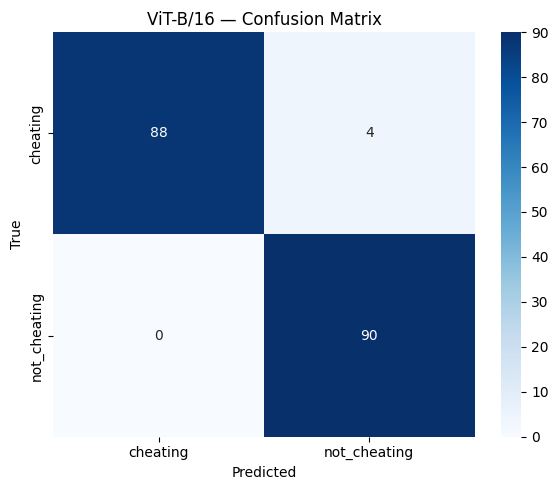

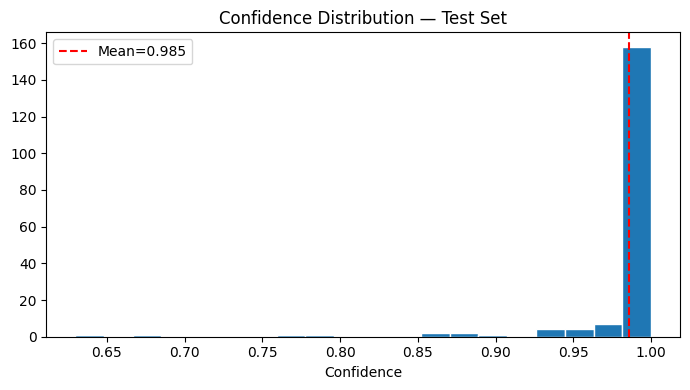

In [ ]:
def run_eval(model, loader):
    model.eval(); ap,al,ab=[],[],[]
    with torch.no_grad():
        for imgs,lbls in loader:
            out=model(imgs.to(device)); prob=F.softmax(out,dim=1); _,p=torch.max(out,1)
            ap.extend(p.cpu().numpy()); al.extend(lbls.numpy()); ab.extend(prob.cpu().numpy())
    return np.array(ap),np.array(al),np.array(ab)

tp,tl,tb = run_eval(model, test_loader)
print("="*55); print(f"  Test Accuracy: {(tp==tl).mean():.4f}"); print("="*55)
print(classification_report(tl, tp, target_names=CLASS_NAMES))

# Confusion matrix
cm=confusion_matrix(tl,tp)
plt.figure(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
plt.title(f"{MODEL_NAME} — Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

# Confidence distribution
confs=tb.max(axis=1)
plt.figure(figsize=(7,4)); plt.hist(confs,bins=20,edgecolor="white")
plt.axvline(confs.mean(),color="red",linestyle="--",label=f"Mean={confs.mean():.3f}")
plt.title("Confidence Distribution — Test Set"); plt.xlabel("Confidence"); plt.legend(); plt.tight_layout(); plt.show()


Wrong predictions: 4/182


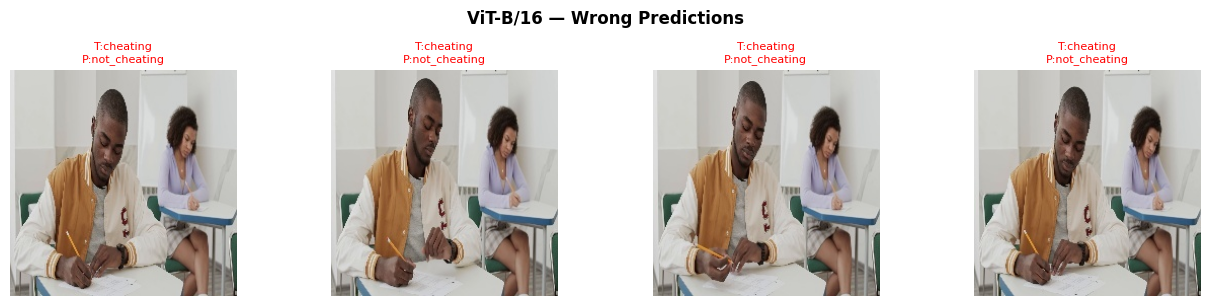

In [ ]:
wi,wp,wt=[],[],[]
model.eval()
with torch.no_grad():
    for imgs,lbls in test_loader:
        out=model(imgs.to(device)); _,preds=torch.max(out,1)
        for i in range(len(lbls)):
            if preds[i].cpu()!=lbls[i]: wi.append(imgs[i]); wp.append(preds[i].cpu().item()); wt.append(lbls[i].item())
print(f"Wrong predictions: {len(wi)}/{len(test_data)}")
if wi:
    n=min(12,len(wi)); plt.figure(figsize=(13,8))
    for i in range(n):
        plt.subplot(3,4,i+1); plt.imshow(unnorm(wi[i],MEAN,STD).permute(1,2,0).clamp(0,1)); plt.axis("off")
        plt.title(f"T:{CLASS_NAMES[wt[i]]}\nP:{CLASS_NAMES[wp[i]]}",color="red",fontsize=8)
    plt.suptitle(f"{MODEL_NAME} — Wrong Predictions",fontweight="bold"); plt.tight_layout(); plt.show()


Train: 0.9848
Val: 0.9945
Test: 0.9780


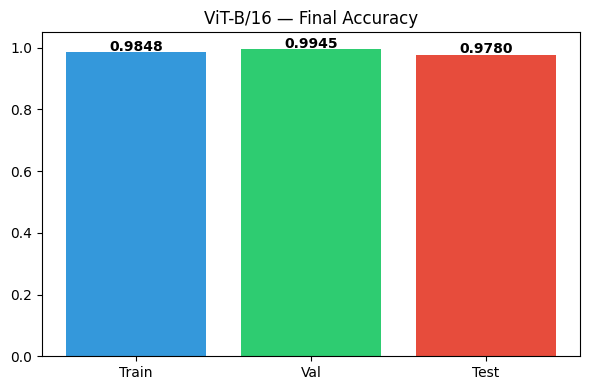

In [ ]:
def split_acc(loader):
    model.eval(); c=t=0
    with torch.no_grad():
        for imgs,lbls in loader:
            imgs,lbls=imgs.to(device),lbls.to(device); _,p=torch.max(model(imgs),1)
            c+=(p==lbls).sum().item(); t+=lbls.size(0)
    return c/t
tr_a=split_acc(train_loader); vl_a=split_acc(val_loader); te_a=split_acc(test_loader)
for n,v in [("Train",tr_a),("Val",vl_a),("Test",te_a)]: print(f"{n}: {v:.4f}")
plt.figure(figsize=(6,4))
bars=plt.bar(["Train","Val","Test"],[tr_a,vl_a,te_a],color=["#3498DB","#2ECC71","#E74C3C"])
for bar,v in zip(bars,[tr_a,vl_a,te_a]): plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,f"{v:.4f}",ha="center",fontweight="bold")
plt.ylim(0,1.05); plt.title(f"{MODEL_NAME} — Final Accuracy"); plt.tight_layout(); plt.show()


Saving WhatsApp Image 2026-05-09 at 3.52.41 PM.jpeg to WhatsApp Image 2026-05-09 at 3.52.41 PM.jpeg


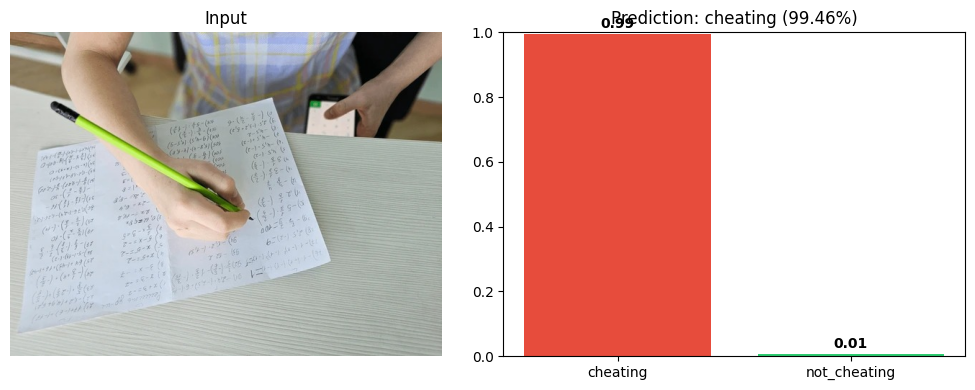

In [ ]:
ext_tf = transforms.Compose([transforms.Resize(IMG_SIZE),transforms.ToTensor(),transforms.Normalize(mean=MEAN,std=STD)])
def predict_external():
    uploaded=files.upload()
    for fn in uploaded:
        img=Image.open(fn).convert("RGB"); t=ext_tf(img).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad(): probs=F.softmax(model(t),dim=1).cpu().numpy()[0]
        pred=probs.argmax()
        fig,ax=plt.subplots(1,2,figsize=(10,4))
        ax[0].imshow(img); ax[0].axis("off"); ax[0].set_title("Input")
        b=ax[1].bar(CLASS_NAMES,probs,color=["#E74C3C","#2ECC71"]); ax[1].set_ylim(0,1)
        for bar,p in zip(b,probs): ax[1].text(bar.get_x()+bar.get_width()/2,p+0.02,f"{p:.2f}",ha="center",fontweight="bold")
        ax[1].set_title(f"Prediction: {CLASS_NAMES[pred]} ({probs[pred]:.2%})")
        plt.tight_layout(); plt.show()
predict_external()


In [ ]:
torch.save(model.state_dict(), MODEL_SAVE)
print(f"💾 Saved → {MODEL_SAVE}")
files.download(MODEL_SAVE)
# Also save to Drive for easy access in the YOLO pipeline
import shutil
drive_models = "/content/drive/MyDrive/saved_models"
os.makedirs(drive_models, exist_ok=True)
shutil.copy(MODEL_SAVE, os.path.join(drive_models, MODEL_SAVE))
print(f"💾 Also saved to Drive: {drive_models}/{MODEL_SAVE}")


💾 Saved → Vision_Transformer.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

💾 Also saved to Drive: /content/drive/MyDrive/saved_models/Vision_Transformer.pth
